## **IMPORTS**

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 853.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 93.5 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image,ImageFilter,ImageEnhance # lib for the image I/O and basic transforms
import os
import math
import json
import glob
import time
import random   # generating the random no.s
from pathlib import Path  # good way to handle the file sytem
from collections import Counter  # dictionary for counting the occurence of each time
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.layers import Conv2D,BatchNormalization,ReLU,Add,Layer,Dropout,MultiHeadAttention,LayerNormalization,Dense,Lambda,MaxPooling2D

# **01—Dataset Preparation**

In [7]:
# before running this command you must upload the zip folder fo the dataset from my github:- https://github.com/iAdityaDev/Optical-Character-Recognition.git
!unzip dataset.zip

Archive:  dataset.zip
   creating: dataset/
   creating: dataset/images/
   creating: dataset/images/train/
  inflating: dataset/images/train/image_001.jpg  
  inflating: dataset/images/train/image_002.jpg  
  inflating: dataset/images/train/image_003.jpg  
  inflating: dataset/images/train/image_004.jpg  
  inflating: dataset/images/train/image_005.jpg  
  inflating: dataset/images/train/image_006.jpg  
  inflating: dataset/images/train/image_007.jpg  
  inflating: dataset/images/train/image_008.jpg  
  inflating: dataset/images/train/image_009.jpg  
  inflating: dataset/images/train/image_010.jpg  
  inflating: dataset/images/train/image_011.jpg  
  inflating: dataset/images/train/image_012.jpg  
  inflating: dataset/images/train/image_013.jpg  
  inflating: dataset/images/train/image_014.jpg  
  inflating: dataset/images/train/image_015.jpg  
  inflating: dataset/images/train/image_016.jpg  
  inflating: dataset/images/train/image_017.jpg  
  inflating: dataset/images/train/image_01

In [2]:
DATASET_FORMAT = 'folder'
TRAIN_IMAGE_DIR = '/content/dataset/images/train'
TRAIN_LABEL_DIR = '/content/dataset/labels/train'
VAL_IMAGE_DIR = '/content/dataset/images/val'
VAL_LABEL_DIR = '/content/dataset/labels/val'
TEST_IMAGE_DIR = '/content/dataset/images/test'
TEST_LABEL_DIR = '/content/dataset/labels/test'
VOCAB_SAVE_PATH = 'vocab.json'
IMG_HEIGHT = 32

# **LOAD DATASET**

In [8]:
def load_folder(img_dir,lbl_dir):
  items = []
  img_dir = Path(img_dir)
  lbl_dir = Path(lbl_dir)
  img_paths = sorted(img_dir.glob('*.jpg'))
  lbl_paths = sorted(lbl_dir.glob('*.txt'))

  for img_path, lbl_path in zip(img_paths, lbl_paths):
      text = lbl_path.read_text(encoding='utf-8').strip()
      if text:
          items.append({'image': str(img_path), 'text': text})
  return items

train_items = load_folder(TRAIN_IMAGE_DIR,TRAIN_LABEL_DIR)
val_items = load_folder(VAL_IMAGE_DIR,VAL_LABEL_DIR)
test_items = load_folder(TEST_IMAGE_DIR,TEST_LABEL_DIR)
print(train_items)
print(val_items)
print(test_items)

print(type(train_items))
print(len(train_items))
print(len(val_items))
print(len(test_items))

[{'image': '/content/dataset/images/train/image_001.jpg', 'text': 'Al'}, {'image': '/content/dataset/images/train/image_002.jpg', 'text': 'INFINITAMENTE AMABLE'}, {'image': '/content/dataset/images/train/image_003.jpg', 'text': 'NIÑO JESUS.'}, {'image': '/content/dataset/images/train/image_004.jpg', 'text': 'A Vos, Dulcissimo Niño'}, {'image': '/content/dataset/images/train/image_005.jpg', 'text': 'JESUS, que no solo os'}, {'image': '/content/dataset/images/train/image_006.jpg', 'text': 'dignasteis de llamaros'}, {'image': '/content/dataset/images/train/image_007.jpg', 'text': 'Doctor de los Niños,'}, {'image': '/content/dataset/images/train/image_008.jpg', 'text': 'sino también de assis-'}, {'image': '/content/dataset/images/train/image_009.jpg', 'text': 'tir como Niño entre los Doctores,'}, {'image': '/content/dataset/images/train/image_010.jpg', 'text': 'se consagra humilde esta pequeña'}, {'image': '/content/dataset/images/train/image_011.jpg', 'text': 'Instrucción de los Niños. Es

# **Visualize Images**

[<Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > <Axes: >
 <Axes: > <Axes: >]


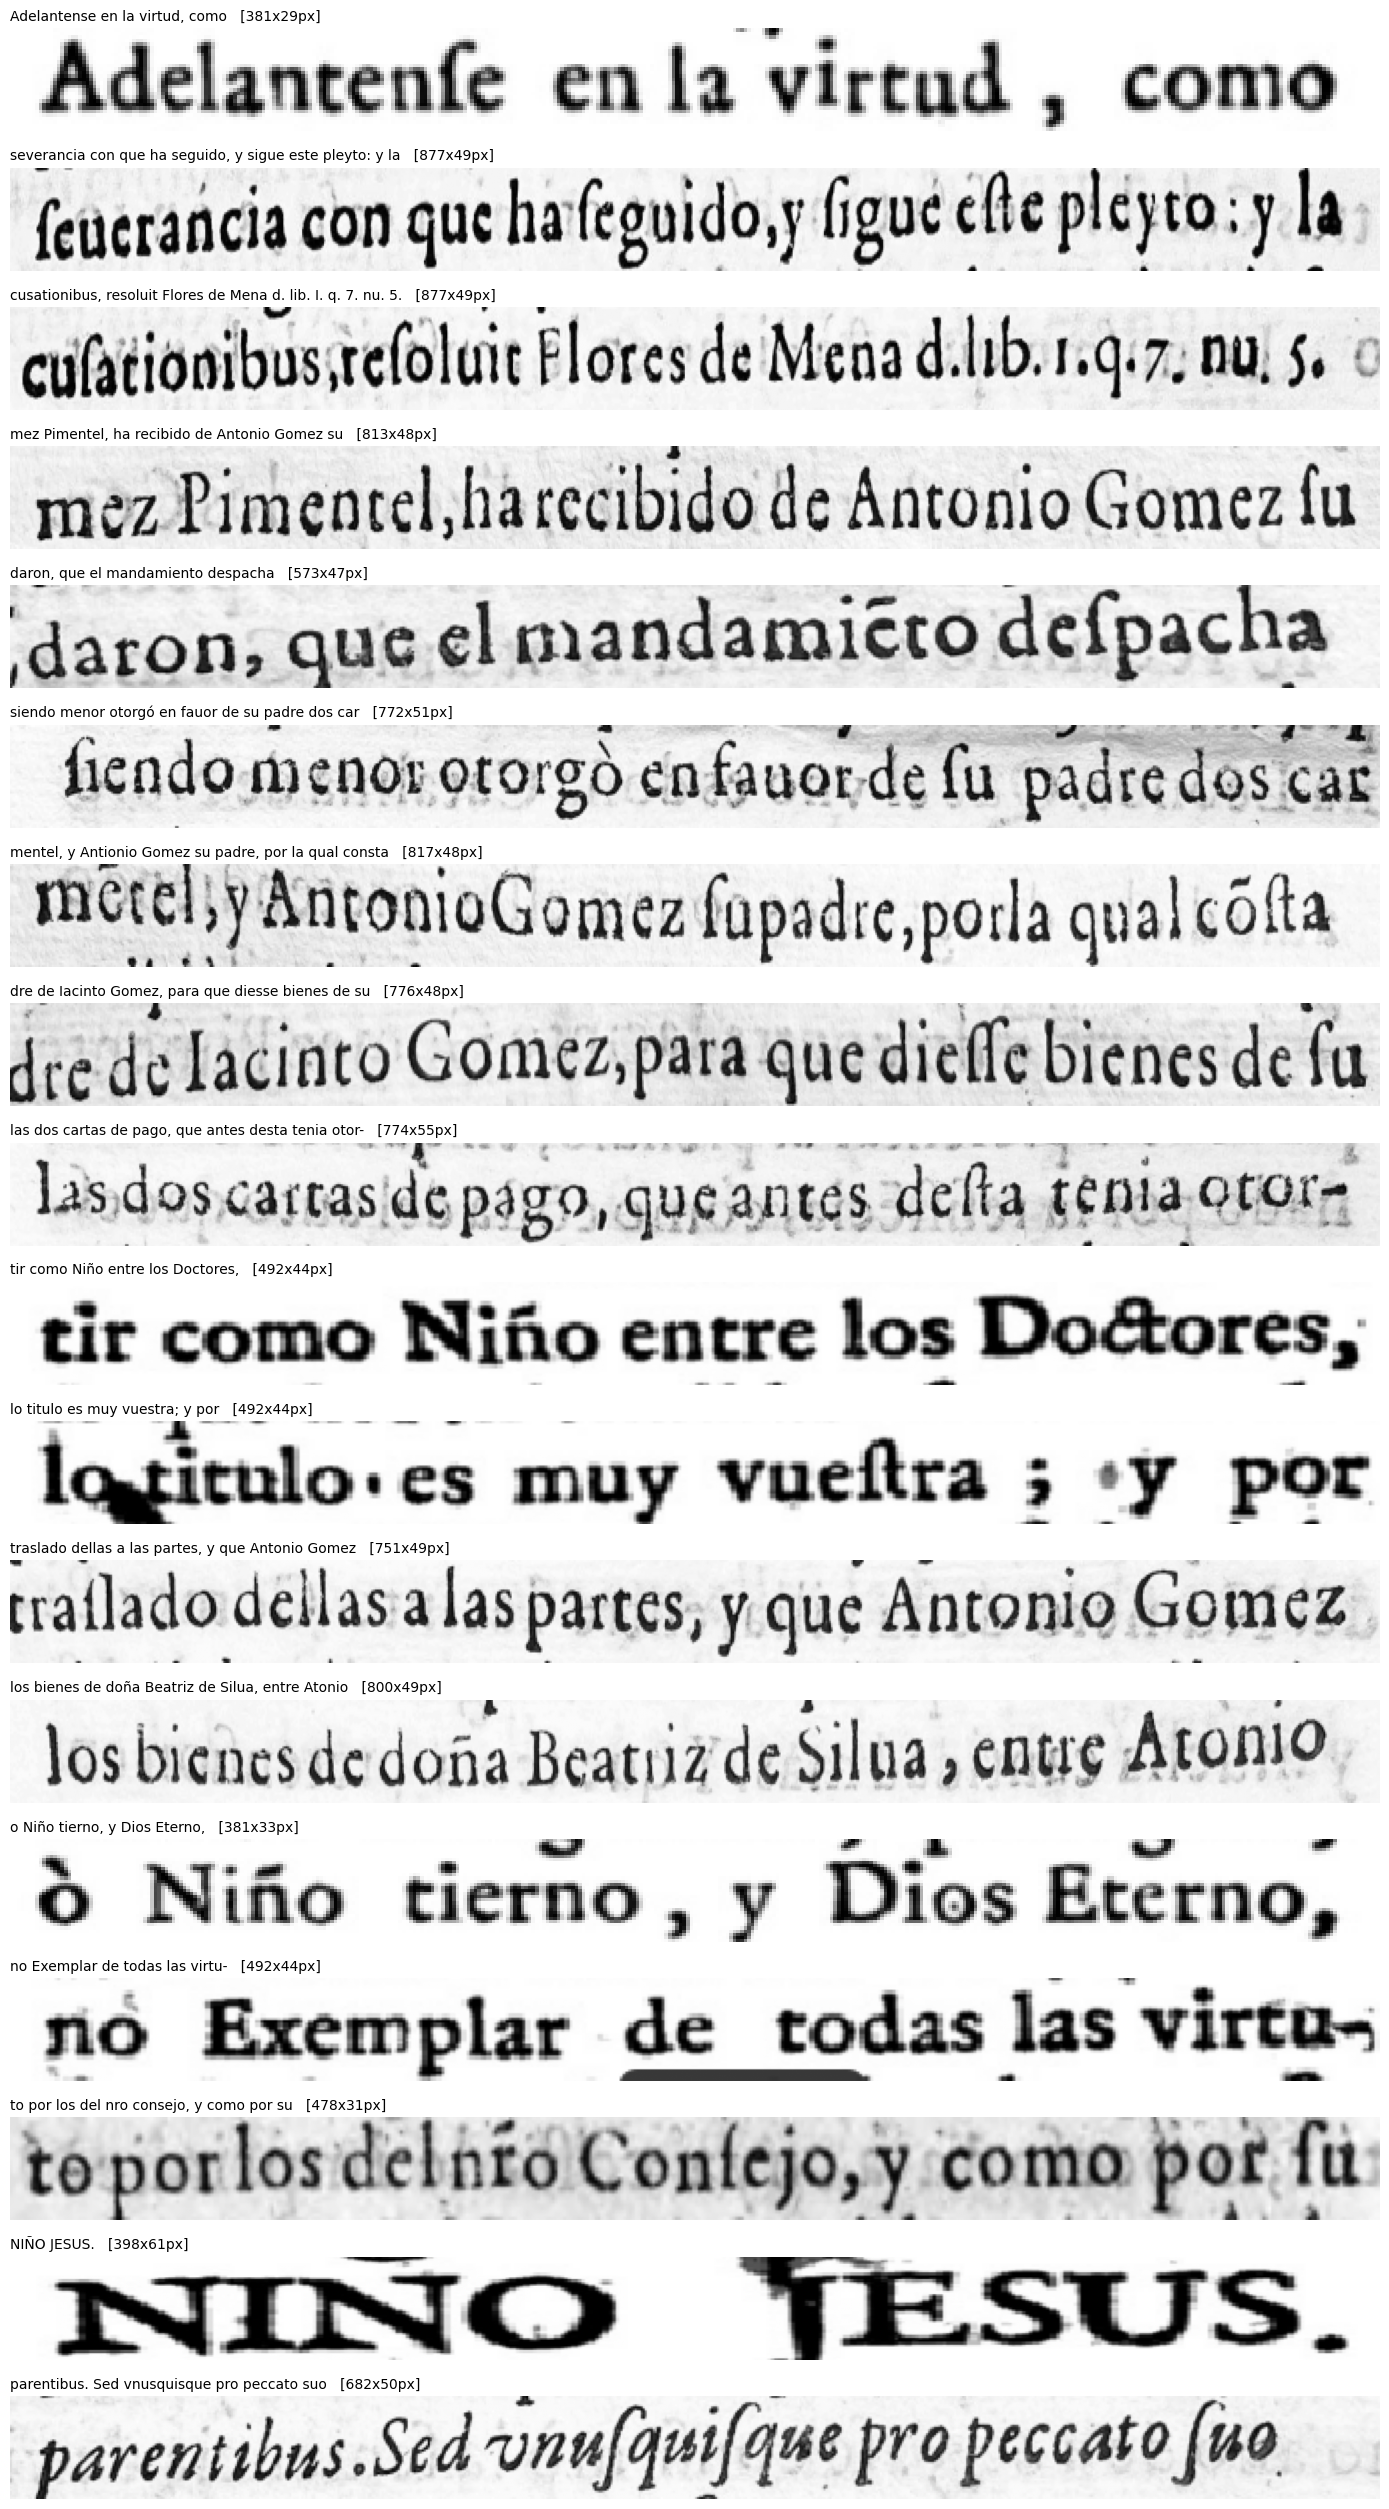

In [9]:
samples = random.sample(train_items, min(18, len(train_items)))
fig, axes = plt.subplots(len(samples), 1, figsize=(14, len(samples) * 1.4))
print(axes)
if len(samples) == 1:
    axes = [axes]

for ax, item in zip(axes, samples):
    img = Image.open(item['image']).convert('L')
    ax.imshow(img, cmap='gray', aspect='auto')
    ax.set_title(f"{item['text']}   [{img.size[0]}x{img.size[1]}px]",
                 fontsize=10, loc='left')
    ax.axis('off')

plt.tight_layout()
plt.show()

# **Character Vocabulary**

In [10]:
# building this vocab cause model works on the mathematical values only thats why making vocab only

char_counter = Counter()
for it in train_items:
    char_counter.update(it['text'])

print(f'20 mostappeared:')
for ch, cnt in char_counter.most_common(20):
    print(f'{repr(ch):8s} {cnt:,}')

# extra_chars = ['Q', '…']
# for ch in extra_chars:
#     char_counter[ch] = 1

val_chars = set()
for it in val_items:
    val_chars.update(it['text'])
unseen = val_chars - set(char_counter.keys())

for ch in unseen:
  char_counter[ch] = 1
unseen = {}
if unseen:
    print(f'{sorted(unseen)}')
else:
    print('unseen in training.')

20 mostappeared:
' '      2,391
'e'      1,558
'a'      1,296
'o'      1,043
's'      862
'i'      778
'r'      771
'n'      747
'd'      642
'l'      555
't'      538
'u'      492
'c'      435
','      290
'm'      290
'p'      286
'y'      180
'q'      157
'g'      126
'-'      105
unseen in training.


In [11]:
sorted_chars = sorted(char_counter.keys())
char2idx = {c: i+1 for  i,c in enumerate(sorted_chars)}
idx2char = {i + 1: c for i, c in enumerate(sorted_chars)}
idx2char[0] = '<blank>'
NUM_CLASSES = len(sorted_chars) + 1
print(NUM_CLASSES)
# print(f'Characters      : {repr("".join(sorted_chars))}')

test_text = train_items[0]['text']

encoded = []
for c in test_text:
  if c in char2idx:
    encoded.append(char2idx[c])
decoded   = ''.join(idx2char[i] for i in encoded)

print(idx2char)

77
{1: ' ', 2: '!', 3: '&', 4: '(', 5: ')', 6: ',', 7: '-', 8: '.', 9: '0', 10: '1', 11: '2', 12: '3', 13: '4', 14: '5', 15: '6', 16: '7', 17: '8', 18: '9', 19: ':', 20: ';', 21: '?', 22: 'A', 23: 'B', 24: 'C', 25: 'D', 26: 'E', 27: 'F', 28: 'G', 29: 'H', 30: 'I', 31: 'J', 32: 'L', 33: 'M', 34: 'N', 35: 'O', 36: 'P', 37: 'Q', 38: 'R', 39: 'S', 40: 'T', 41: 'U', 42: 'V', 43: 'Y', 44: 'Z', 45: 'a', 46: 'b', 47: 'c', 48: 'd', 49: 'e', 50: 'f', 51: 'g', 52: 'h', 53: 'i', 54: 'j', 55: 'l', 56: 'm', 57: 'n', 58: 'o', 59: 'p', 60: 'q', 61: 'r', 62: 's', 63: 't', 64: 'u', 65: 'v', 66: 'x', 67: 'y', 68: 'z', 69: 'Ñ', 70: 'á', 71: 'ç', 72: 'é', 73: 'í', 74: 'ñ', 75: 'ó', 76: '…', 0: '<blank>'}


In [12]:
sorted_chars = sorted(char_counter.keys())
char2idx = {c: i+1 for  i,c in enumerate(sorted_chars)}
idx2char = {i + 1: c for i, c in enumerate(sorted_chars)}
idx2char[0] = '<blank>'
NUM_CLASSES = len(sorted_chars) + 1
print(NUM_CLASSES)


test_text = train_items[0]['text']
encoded   = [char2idx[c] for c in test_text if c in char2idx]
decoded   = ''.join(idx2char[i] for i in encoded)
print(encoded)
print(decoded)

77
[22, 55]
Al


In [13]:
###saving this so that i can reuse it later without generating vocab again again
vocab_data = {
    'chars'      : sorted_chars,
    'num_classes': NUM_CLASSES,
    'char2idx'   : char2idx,
    'note'       : 'Index 0 is CTC blank. Characters start at index 1.'
}

with open(VOCAB_SAVE_PATH, 'w', encoding='utf-8') as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)


In [14]:
def filter_items(items, char2idx):
    kept, dropped = [], []
    for it in items:
        encoded = [char2idx[c] for c in it['text'] if c in char2idx]
        if len(encoded) > 0:
            it['encoded'] = encoded
            kept.append(it)
        else:
            dropped.append(it)
    return kept, dropped

train_items, train_dropped = filter_items(train_items, char2idx)
val_items,   val_dropped   = filter_items(val_items,   char2idx)

print(f'{len(val_items)}')

####json files for train_items and val_itmes again so that i can give use it later
with open('train_items.json', 'w') as f:
    json.dump(train_items, f ,  indent=2)
with open('val_items.json', 'w') as f:
    json.dump(val_items, f ,  indent=2)

73


# **02—Model Building**

**HyperParameters**

In [15]:
IMG_HEIGHT   = 32
D_MODEL      = 64
NUM_HEADS    = 4
NUM_LAYERS   = 2
D_FF         = 128
DROPOUT      = 0.1

In [16]:
def conv_bn_relu(x,filters,kernel_size=3,strides=1,padding='same'):
  x = Conv2D(filters,kernel_size,strides=strides,padding=padding,use_bias = False)(x)
  x = BatchNormalization()(x)
  x = ReLU()(x)
  return x

def residual_block(x, filters, strides=1):
    shortcut = x

    out = Conv2D(filters, 3, strides=strides,
                        padding='same', use_bias=False)(x)
    out = BatchNormalization()(out)
    out = ReLU()(out)
    out = Conv2D(filters, 3, padding='same', use_bias=False)(out)
    out = BatchNormalization()(out)

    if strides != 1 or x.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=strides,
                                 use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Add()([out, shortcut])
    out = ReLU()(out)
    return out

def build_cnn_backbone(x, out_channels):
    x = conv_bn_relu(x, 64, 3)
    x = MaxPooling2D(2, padding='same')(x)

    x = residual_block(x, 128, strides=2)
    x = residual_block(x, 128, strides=1)

    x = residual_block(x, 256, strides=2)


    # x = residual_block(x, 128, strides=1)


    # x = Conv2D(out_channels, 8, strides=(3, 3),padding='same', use_bias=False)(x)
    # x = BatchNormalization()(x)
    # x = ReLU()(x)


    x = residual_block(x, 256, strides=1)


    x = Conv2D(out_channels, 3, strides=(1, 1),padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(out_channels, 3, strides=(1, 1),padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x

print('CNN formed')


CNN formed


**Positional Encoding**

In [17]:
@register_keras_serializable()
class SinusoidalPositionalEncoding(Layer):
  def __init__(self,d_model,max_len=2048,dropout_rate=0.1,**kwargs):
    super().__init__(**kwargs)
    self.dropout = Dropout(dropout_rate)

    # encoding table in numpy
    pe = np.zeros((max_len,d_model),dtype=np.float32)
    pos = np.arange(max_len)[:,np.newaxis]


    div = np.exp(np.arange(0,d_model,2)*(-math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(pos*div)
    pe[:, 1::2] = np.cos(pos*div)
    self._pe = pe[np.newaxis]

  def call(self, x, training=False):
      T  = tf.shape(x)[1]
      pe = tf.constant(self._pe, dtype=tf.float32)


      x  = x + pe[:, :T, :]
      return self.dropout(x, training=training)

**Transformer Encoder**

In [18]:
@register_keras_serializable()
class TransformerEncoderLayer(Layer):
  def __init__(self,d_model,num_heads,d_ff,dropout_rate=0.1,**kwargs):
    super().__init__(**kwargs)
    self.attn = MultiHeadAttention(num_heads=num_heads,key_dim=d_model//num_heads,dropout=dropout_rate)
    self.ffn = Sequential([
        Dense(d_ff,activation='relu'),
        Dropout(dropout_rate),
        Dense(d_model)
    ])
    self.norm1 = LayerNormalization(epsilon=1e-6)
    self.norm2 = LayerNormalization(epsilon=1e-6)
    self.drop1 = Dropout( dropout_rate)
    self.drop2 = Dropout( dropout_rate)

  def call(self,x,training=False):
    normed = self.norm1(x)
    attn_out = self.attn(normed,normed,training=training)
    #sub layer feed forward
    x = x + self.drop2(self.ffn(self.norm2(x),training=training),training=training)
    return x

@register_keras_serializable()
class TransformerEncoder(Layer):
  ###stack on may encoder layers
  def __init__(self,d_model,num_heads,num_layers,d_ff,dropout_rate=0.1,**kwargs):
     super().__init__(**kwargs)
     self.layers_ = [
         TransformerEncoderLayer(d_model,num_heads,d_ff,dropout_rate,name=f'enc_{i}')
         for i in range(num_layers)
     ]
     self.norm = LayerNormalization(epsilon=1e-6)
  def call(self,x,training=False):
    for layer in self.layers_ :
      x = layer(x,training=training)
    return self.norm(x)

In [19]:
@register_keras_serializable()
class PoolHeight(keras.layers.Layer):
    def call(self,t):
        return tf.reduce_mean(t, axis=1)

    def compute_output_shape(self, input_shape):
        # (B, H, W, C) -> (B, W, C)
        return (input_shape[0], input_shape[2])

@register_keras_serializable()
class LogSoftmax(keras.layers.Layer):
    def call(self,t):
        return tf.nn.log_softmax(t, axis=-1)

    def compute_output_shape(self, input_shape):
        return input_shape

def build_ocr_model(num_classes, img_height=32, d_model=256,num_heads=4, num_layers=3, d_ff=512, dropout=0.1):

    images = keras.Input(shape=(img_height, None, 1), name='images')

    feat = build_cnn_backbone(images, out_channels=d_model)


    feat = PoolHeight(name='pool_height')(feat)

    feat = SinusoidalPositionalEncoding(d_model, dropout_rate=dropout, name='pos_enc')(feat)

    feat = TransformerEncoder(d_model, num_heads, num_layers, d_ff,dropout_rate=dropout, name='transformer')(feat)

    logits    = Dense(num_classes, name='logits')(feat)

    log_probs = LogSoftmax(name='log_probs')(logits)
    return keras.Model(inputs=images, outputs=log_probs, name='OCRModel')


model = build_ocr_model(
    num_classes = NUM_CLASSES,
    img_height  = IMG_HEIGHT,
    d_model     = D_MODEL,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    d_ff        = D_FF,
    dropout     = DROPOUT
)

model.summary(line_length=80)

Model: "OCRModel"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)   │ (None, 32, None,  │           0 │ -                  │
│                       │ 1)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, 32, None,  │         576 │ images[0][0]       │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 32, None,  │         256 │ conv2d[0][0]       │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, 32, None,  │           0 │ batch_normalizati… │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, 16, None,  │           0 │ re_lu[0][0]        │
│ (MaxPooling2D)        │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, 8, None,   │      73,728 │ max_pooling2d[0][… │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 8, None,   │         512 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, 8, None,   │           0 │ batch_normalizati… │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, 8, None,   │     147,456 │ re_lu_1[0][0]      │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, 8, None,   │       8,192 │ max_pooling2d[0][… │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 8, None,   │         512 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_3 │ (None, 8, None,   │         512 │ conv2d_3[0][0]     │
│ (BatchNormalization)  │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add (Add)             │ (None, 8, None,   │           0 │ batch_normalizati… │
│                       │ 128)              │             │ batch_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, 8, None,   │           0 │ add[0][0]          │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, 8, None,   │     147,456 │ re_lu_2[0][0]      │
│                       │ 128)              │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_4 │ (None, 8, None,   │         512 │ conv2d_4[0][0]     │
│ (BatchNormalization)  │ 128) 

 Total params: 2,886,861 (11.01 MB)

 Trainable params: 2,882,637 (11.00 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [20]:
def ctc_greedy_decode(log_probs, idx2char, blank_idx=0):

    best = tf.argmax(log_probs, axis=-1).numpy()
    print(best.shape[0])
    results = []
    for b in range(best.shape[0]):
        path = best[b].tolist()
        # Collapse repeats
        collapsed = [path[0]]
        for tok in path[1:]:
            if tok != collapsed[-1]:
                collapsed.append(tok)
        # blanks removal
        decoded = [t for t in collapsed if t != blank_idx]
        results.append(''.join(idx2char.get(t, '?') for t in decoded))
    return results


dummy   = tf.zeros([1, IMG_HEIGHT, 320, 1])
out     = model(dummy, training=False)
decoded = ctc_greedy_decode(out, idx2char)

1


# **Training**

In [27]:
EPOCHS       = 50
BATCH_SIZE   = 8
LEARNING_RATE = 1e-3
CHECKPOINT_DIR = 'checkpoints'
Path(CHECKPOINT_DIR).mkdir(exist_ok=True)

In [22]:
def augment(img):
    if random.random() < 0.15:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.2)))
    if random.random() < 0.3:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.75, 1.3))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.25))
    if random.random() < 0.2:
        arr = np.array(img, dtype=np.float32)
        arr = np.clip(arr + np.random.randn(*arr.shape) * random.uniform(2, 6),0, 255).astype(np.uint8)
        img = Image.fromarray(arr)
    return img

In [24]:
def load_and_preprocess(path, label, text):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    new_w = tf.cast(tf.shape(img)[1], tf.float32) * IMG_HEIGHT / tf.cast(tf.shape(img)[0], tf.float32)
    img = tf.image.resize(img, [IMG_HEIGHT, tf.cast(new_w, tf.int32)])
    img = tf.cast(img, tf.float32) / 127.5 - 1.0
    return img, label, text


def make_dataset(items, shuffle):
    paths  = [it['image'] for it in items]
    labels = [it['encoded'] for it in items]
    texts  = [it['text']    for it in items]

    # pats  = [it['image'] for it in items]
    # laels = [it['encoded'] for it in items]
    # texts  = [it['text']    for it in items]

    max_len = max(len(l) for l in labels)
    labels_padded = [l + [0] * (max_len - len(l)) for l in labels]

    path_ds  = tf.data.Dataset.from_tensor_slices(paths)
    label_ds = tf.data.Dataset.from_tensor_slices(
        tf.constant(labels_padded, dtype=tf.int32)
    )
    text_ds  = tf.data.Dataset.from_tensor_slices(texts)

    ds = tf.data.Dataset.zip((path_ds, label_ds, text_ds))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(items), reshuffle_each_iteration=True)

    return (
        ds
        .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .padded_batch(
            BATCH_SIZE,
            padded_shapes=([IMG_HEIGHT, None, 1], [None], []),
            padding_values=(-1.0, 0, '')
        )
        # .prefetch(1)
    )

train_ds = make_dataset(train_items, shuffle=True)
val_ds   = make_dataset(val_items,   shuffle=False)

print(f'{len(train_items)} {len(train_items)/BATCH_SIZE}')
print(f'{len(val_items)} ')

380 47.5
73 


**CTC loss and optimizer**

In [25]:
def compute_ctc_loss(log_probs, labels, images):
    B = tf.shape(log_probs)[0]
    T = tf.shape(log_probs)[1]

    seq_lengths = tf.fill([B], T)

    label_lengths = tf.cast(
        tf.math.count_nonzero(labels, axis=1), tf.int32
    )

    logits_tm = tf.transpose(tf.cast(log_probs, tf.float32), [1, 0, 2])

    loss = tf.nn.ctc_loss(
        labels            = tf.cast(labels, tf.int32),
        logits            = logits_tm,
        label_length      = label_lengths,
        logit_length      = seq_lengths,
        logits_time_major = True,
        blank_index       = 0,
    )
    return tf.reduce_mean(loss)

try:
    optimizer = keras.optimizers.AdamW(learning_rate=LEARNING_RATE,weight_decay=1e-4, clipnorm=5.0)
except AttributeError:
    try:
        optimizer = keras.optimizers.experimental.AdamW(
            learning_rate=LEARNING_RATE, weight_decay=1e-4, clipnorm=5.0)
    except AttributeError:
        optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=5.0)

In [28]:
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        log_probs = model(images, training=True)
        loss = compute_ctc_loss(log_probs, labels, images)
    grads = tape.gradient(loss, model.trainable_weights)
    grads = [g if g is not None else tf.zeros_like(w)
             for g, w in zip(grads, model.trainable_weights)]
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    return loss


def ctc_greedy_decode(log_probs):
    best = tf.argmax(log_probs, axis=-1).numpy()
    results = []
    for row in best:
        col = [row[0]]
        # for t in row[1:]:

        for t in row[1:]:
            if t != col[-1]: col.append(t)
        results.append(''.join(idx2char.get(int(t), '') for t in col if t != 0))
    return results


def levenshtein(s1, s2):
    if s1 == s2: return 0
    if len(s1) < len(s2): s1, s2 = s2, s1
    prev = list(range(len(s2)+1))

    for c1 in s1:
        cur = [prev[0]+1]
        for j, c2 in enumerate(s2):
            cur.append(min(prev[j]+(0 if c1==c2 else 1), cur[-1]+1, prev[j+1]+1))
        prev = cur
    return prev[-1]


def val_epoch():
    preds, gts, total_loss, n = [], [], 0.0, 0
    for batch in val_ds:
        lp   = model(batch[0], training=False)
        loss = compute_ctc_loss(lp, batch[1], batch[0])
        total_loss += float(loss); n += 1
        preds.extend(ctc_greedy_decode(lp))
        gts.extend([t.numpy().decode() for t in batch[2]])

    tot_dist = sum(levenshtein(g, p) for g, p in zip(gts, preds))
    tot_len  = sum(len(g) for g in gts)
    cer = tot_dist / max(tot_len, 1)
    return total_loss / max(n, 1), cer


history = {'train_loss': [], 'val_loss': [], 'cer': []}
best_cer = float('inf')

for epoch in range(1, EPOCHS + 1):
    t0, train_losses = time.time(), []

    for batch in train_ds:
        loss = train_step(batch[0], batch[1])
        train_losses.append(float(loss))
        del batch

    val_loss, cer = val_epoch()
    avg_loss = sum(train_losses) / max(len(train_losses), 1)
    elapsed  = time.time() - t0

    history['train_loss'].append(avg_loss)
    history['val_loss'].append(val_loss)
    history['cer'].append(cer)

    marker = ''
    if cer < best_cer:
        best_cer = cer
        model.save(f'{CHECKPOINT_DIR}/best.keras')
        marker = '  ← best'

    print(f'Epoch {epoch:03d}/{EPOCHS}'
          f'loss: {avg_loss:.2f}'
          f'val_loss: {val_loss:.4f}'
          f'CER: {cer:.4f}')

Epoch 001/2loss: 132.04val_loss: 142.8681CER: 0.9595


KeyboardInterrupt: 

In [ ]:
model.save(f'{CHECKPOINT_DIR}/best.keras')

In [30]:
# model = keras.models.load_model(
#     'checkpoints/best.keras',
#     custom_objects={
#         'PoolHeight': PoolHeight,
#         'LogSoftmax': LogSoftmax, ## earlier these classes were not serialised that's imported them
#     },
#     safe_mode=False
# )

model = keras.models.load_model(
    '/content/best.keras',safe_mode=False
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'transformer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [31]:
def preprocess(path, img_height=64):
    img = Image.open(path).convert('L')
    w, h = img.size
    new_w = max(1, int(w * img_height / h))
    img = img.resize((new_w, img_height), Image.BICUBIC)
    arr = np.array(img, dtype=np.float32)/127.5 - 1.0
    return tf.constant(arr[np.newaxis, :, :, np.newaxis], dtype=tf.float32)


def ctc_greedy_decode(log_probs, idx2char, blank=0):
    best = tf.argmax(log_probs, axis=-1).numpy()
    results = []
    for row in best:
        col = [row[0]]
        for t in row[1:]:
            if t != col[-1]: col.append(t)
        results.append(''.join(idx2char.get(int(t), '') for t in col if t != blank))
    return results

all_preds, all_gts = [], []

for i, item in enumerate(val_items):
    tensor = preprocess(item['image'], IMG_HEIGHT)
    lp     = model(tensor, training=False)
    pred   = ctc_greedy_decode(lp, idx2char)[0]
    all_preds.append(pred)
    all_gts.append(item['text'])
    if (i + 1) % 200 == 0:
        print(f'  {i+1}/{len(val_items)} done')

# **Testing**

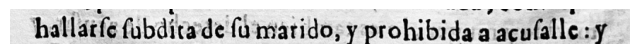

Predicted text: "hallarse sibdita de su marido, y probibida a acusalle y"



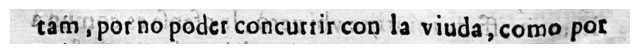

Predicted text: "tam, por no poder concurir con la viuda, como por"



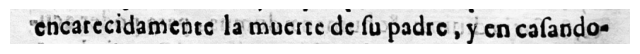

Predicted text: "encarecidamente la muerte de su padre, y en casando"



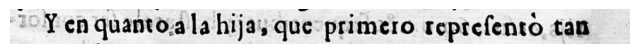

Predicted text: "Y en quanto a la hija, que primero re presento tan"



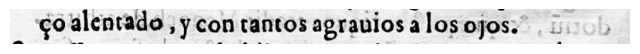

Predicted text: "qo alentado, y eon tanto agravios a los opos..i"



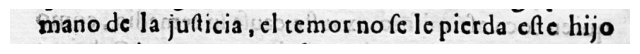

Predicted text: "rmano de la justicia, l temor no se le pierda este hijo"



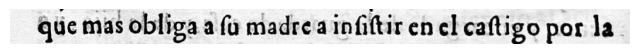

Predicted text: " que mas obliga a su madre a insistir en el castigo por la"



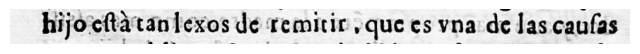

Predicted text: "hijo esta tan lexos de remitir, que es vna de las causas"



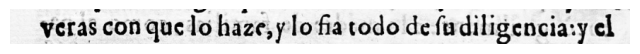

Predicted text: " veras con que lo har,y lo fia todo de su diligencia y el"



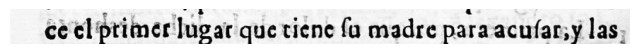

Predicted text: "ce el primer luvgar que tiene su madre para acuar,y las,"



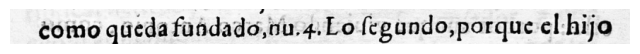

Predicted text: " como queda fundado, nu. 4 Lo segundo, porque el hijo"



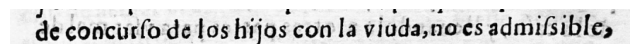

Predicted text: "de concurso de los hijos con la riuda, no es admisible,"



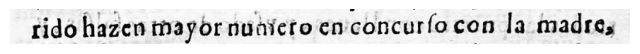

Predicted text: "rido hazen may or numero en concurso con la madre,"



In [43]:
FOLDER_PATH = '/content/dataset/images/test/'
TEST_IMAGE = FOLDER_PATH + '*.jpg'

# 2. Use glob to find all matching files
IMAGE_PATHS = glob.glob(TEST_IMAGE)
IMAGE_PATHS.sort(reverse=True)
for path in IMAGE_PATHS:
    img = Image.open(path).convert('L')
    plt.figure(figsize=(8, 3))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

    tensor = preprocess(path, IMG_HEIGHT)
    lp     = model(tensor, training=False)
    pred   = ctc_greedy_decode(lp, idx2char)[0]

    print(f'Predicted text: "{pred}"\n')